<a href="https://colab.research.google.com/github/Hafeez1002/CDA/blob/main/OM_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### Install Packages
First, install and load the necessary packages.
We will be using a purpose built Python package for importing and using argo data: argopy.

In [17]:
!pip install argopy xarray matplotlib cartopy numpy regionmask cmocean


In [18]:
from argopy import DataFetcher
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask
import cmocean

### Download the data
 In this example we will download data from argo floats that were in the Gulf Stream region of the North Atlantic in August of 2025.
 The function DataFetcher using the method .region() allows you to choose the latitude, longitude, pressure and date ranges you wish to load. You can also use methods .float() and .(profile) to load specific floats or profiles.

point2profile() converts the default individual point measurements into profiles of measurements which will be easier to work with. ds is then an xarray Dataset. You can view the co-ordinates and variables in the data set by printing ds.

In [33]:
lon_min = -88
lon_max = -60

lat_min = 22
lat_max = 40

depth_min = 0
depth_max = 500

start_date = "2019-08-15"
end_date   = "2019-08-31"

ArgoSet = DataFetcher(mode='expert').region(
    [lon_min, lon_max,
     lat_min, lat_max,
     depth_min, depth_max,
     start_date, end_date]
).load()


ds = ArgoSet.data.argo.point2profile()
ds

<xarray.Dataset> Size: 4MB
Dimensions:                   (N_PROF: 129, N_LEVELS: 441)
Coordinates:
  * N_PROF                    (N_PROF) int64 1kB 22 33 16 111 48 ... 66 11 75 96
  * N_LEVELS                  (N_LEVELS) int64 4kB 0 1 2 3 4 ... 437 438 439 440
    LATITUDE                  (N_PROF) float64 1kB 24.0 26.45 ... 35.44 24.89
    LONGITUDE                 (N_PROF) float64 1kB -82.38 -62.07 ... -84.96
    TIME                      (N_PROF) datetime64[ns] 1kB 2019-08-15T02:04:47...
Data variables: (12/23)
    CONFIG_MISSION_NUMBER     (N_PROF) int64 1kB 5 5 6 3 5 3 5 ... 3 3 5 1 2 6 3
    CYCLE_NUMBER              (N_PROF) int64 1kB 200 191 249 11 ... 86 59 165 15
    DATA_MODE                 (N_PROF) <U1 516B 'D' 'D' 'D' 'D' ... 'D' 'D' 'D'
    DIRECTION                 (N_PROF) <U1 516B 'A' 'A' 'A' 'A' ... 'A' 'A' 'A'
    PLATFORM_NUMBER           (N_PROF) int64 1kB 4901596 4901700 ... 4903232
    POSITION_QC               (N_PROF) int64 1kB 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1
    ...                        ...
    TEMP_ADJUSTED             (N_PROF, N_LEVELS) float32 228kB 31.37 ... nan
    TEMP_ADJUSTED_ERROR       (N_PROF, N_LEVELS) float32 228kB 0.002 ... nan
    TEMP_ADJUSTED_QC          (N_PROF, N_LEVELS) int64 455kB 1 1 ... 99999 99999
    TEMP_QC                   (N_PROF, N_LEVELS) int64 455kB 1 1 ... 99999 99999
    TIME_QC                   (N_PROF) int64 1kB 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1
    VERTICAL_SAMPLING_SCHEME  (N_PROF) <U207 107kB 'Primary sampling: average...
Attributes:
    DATA_ID:              ARGO
    DOI:                  http://doi.org/10.17882/42182
    Fetched_from:         erddap.ifremer.fr
    Fetched_by:           root
    Fetched_date:         2026/02/19
    Fetched_constraints:  [x=-88.00/-60.00; y=22.00/40.00; z=0.0/500.0; t=201...
    Fetched_uri:          https://erddap.ifremer.fr/erddap/tabledap/ArgoFloat...
    Processing_history:   Transformed with 'point2profile'

Plot the locations of the profiles using cartopy

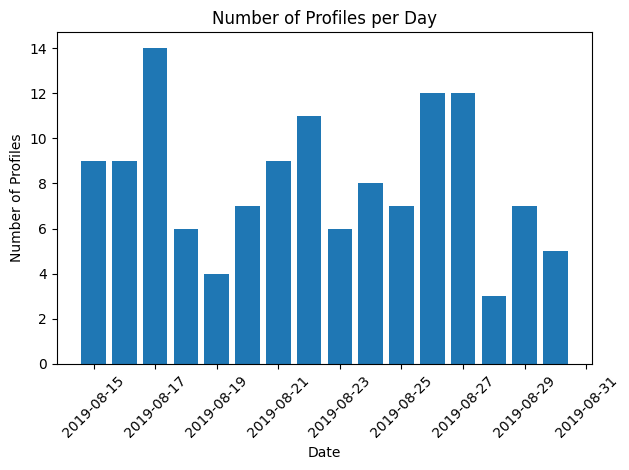

In [34]:
daily_counts = ds["TIME"].resample(TIME="1D").count()

plt.figure()
plt.bar(daily_counts["TIME"], daily_counts.values)
plt.xlabel("Date")
plt.ylabel("Number of Profiles")
plt.title("Number of Profiles per Day")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

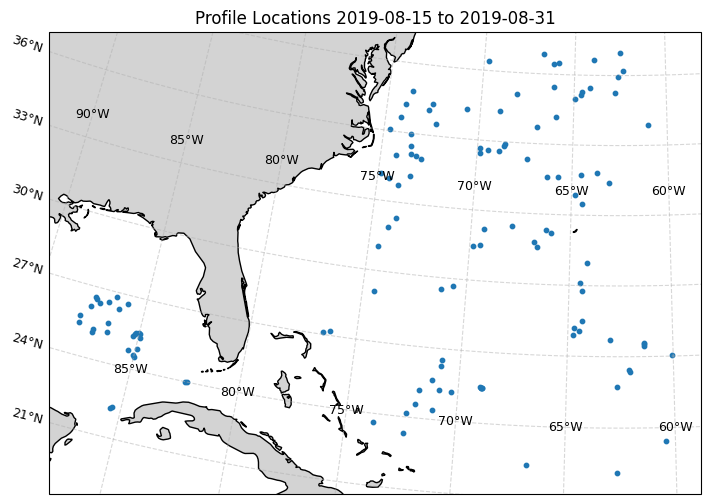

In [35]:
fig = plt.figure(figsize=(10, 6))

proj = ccrs.LambertConformal(
    central_longitude=-62.5,   # midpoint of lon range
    central_latitude=37.5,     # midpoint of lat range
    standard_parallels=(30, 45) # latitudes of minimal distortion
)

ax = plt.axes(projection=proj)

ax.scatter(
    ds['LONGITUDE'],
    ds['LATITUDE'],
    s=10,
    transform=ccrs.PlateCarree()
)

ax.coastlines()
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.BORDERS, linestyle=':')
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
gl.left_labels = True
gl.bottom_labels = True
gl.xlabel_style = {'size': 9}
gl.ylabel_style = {'size': 9}

ax.set_title("Profile Locations")
title = f"Profile Locations {start_date} to {end_date}"
plt.title(title)
plt.show()

Let's extract the temperature data and plot the depth average over the top 500 m


In [36]:
temperature = ds.TEMP
lat = ds.LATITUDE
lon = ds.LONGITUDE

temp_mean = ds.TEMP.mean(dim='N_LEVELS')

In [62]:
salinity = ds.PSAL
lat = ds.LATITUDE
lon = ds.LONGITUDE

sal_mean = ds.PSAL.mean(dim='N_LEVELS')

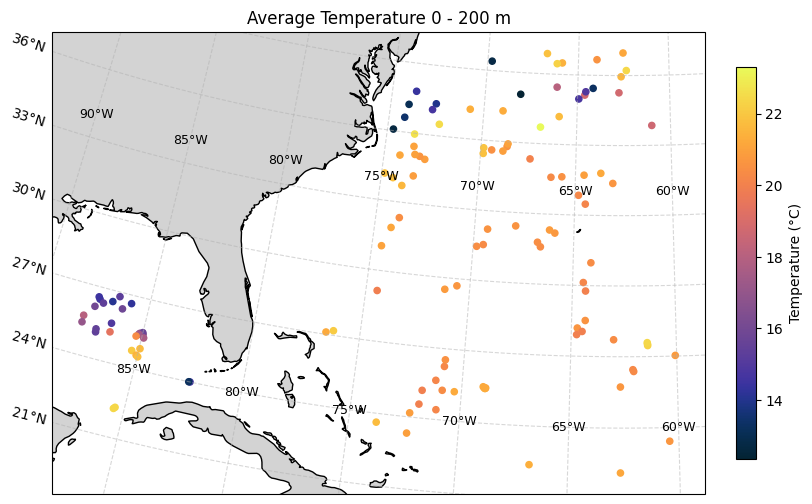

In [37]:
fig = plt.figure(figsize=(10, 6))

ax = plt.axes(projection=proj)

sc = ax.scatter(
    lon,
    lat,
    c=temp_mean,
    cmap=cmocean.cm.thermal,
    s=20,
    transform=ccrs.PlateCarree()
)

ax.coastlines()
ax.add_feature(cfeature.LAND, facecolor='lightgray')
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 9, 'rotation': 0, 'ha': 'center'}

cbar = plt.colorbar(
    sc,
    ax=ax,
    fraction=0.035,
    pad=0.04,
    shrink=0.85
)
cbar.set_label("Temperature (°C)")

ax.set_title("Average Temperature 0 - 200 m")

plt.show()

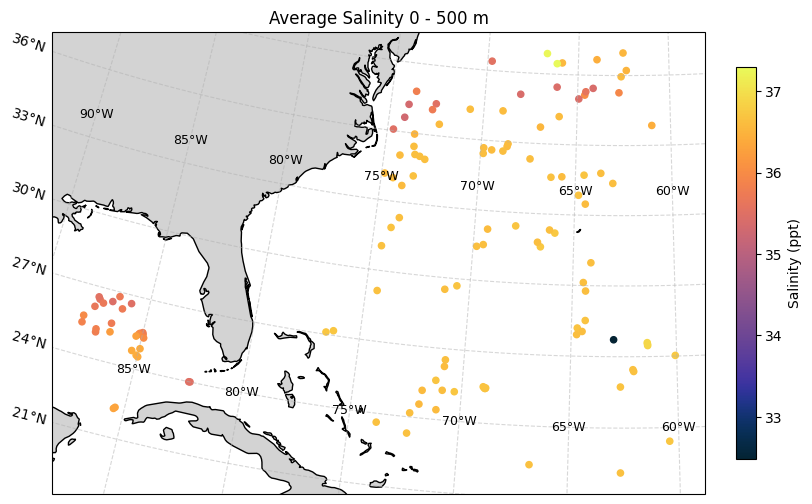

In [63]:
fig = plt.figure(figsize=(10, 6))

ax = plt.axes(projection=proj)

sc = ax.scatter(
    lon,
    lat,
    c=sal_mean,
    cmap=cmocean.cm.thermal,
    s=20,
    transform=ccrs.PlateCarree()
)

ax.coastlines()
ax.add_feature(cfeature.LAND, facecolor='lightgray')
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 9, 'rotation': 0, 'ha': 'center'}

cbar = plt.colorbar(
    sc,
    ax=ax,
    fraction=0.035,
    pad=0.04,
    shrink=0.85
)
cbar.set_label("Salinity (ppt)")

ax.set_title("Average Salinity 0 - 500 m")

plt.show()

Now, we start calculating the estimate of the temperature using objective function fitting to estiate the mean and an objective map to estimate the fluctuation part. Suppose the data $\mathbf{T}$ can be decomposed into a mean, a fluctuating part and noise: $$\mathbf{T} = \langle\mathbf{T}\rangle + \mathbf{T^\prime} + \mathbf{n}.$$
Here, we will assume that the mean can be described by a linear plane fit.
The estimate is then $\hat{\mathbf{T}} = \mathbf{a}\mathbf{T}$ where $\mathbf{a}$ is the gain given by $$\mathbf{a}=\mathbf{E}^{-1} \mathbf{F}\left(\mathbf{F}^T \mathbf{E}^{-1} \mathbf{F}\right)^{-1} \mathbf{f}+\left[\mathbf{I}-\mathbf{E}^{-1} \mathbf{F}\left(\mathbf{F}^T \mathbf{E}^{-1} \mathbf{F}\right)^{-1} \mathbf{F}^T\right] \mathbf{E}^{-1} \mathbf{C}.$$

$\mathbf{F}$ is the matrix of functions, which for a plane fit is: $$ \mathbf{F}=\left[\begin{array}{ccc}
x_1 & y_1 & 1 \\
\vdots & \vdots & \vdots \\
x_n & y_n & 1
\end{array}\right],  $$
and $\mathbf{f}$ is the matrix of these basis functions evaluated at each of the grid points.

Therefore, we need to calculate the data-data covariance matrix $\mathbf{E} = \langle(\mathbf{T^\prime} + \mathbf{n})(\mathbf{T^\prime} + \mathbf{n})^T\rangle$ and the data-grid point covariance matrix $\mathbf{C}=\langle\mathbf{T}^{\prime}T^{\prime}(x,y)$. If we assume the fluctuating part of the temperature field is anisotropic with Gaussian autocovariance:
$$C(x,y) = \exp\Big[ - \frac{dx^2}{L_x^2} - \frac{dy^2}{L_y^2}\Big].$$
Here, $dx$ and $dy$ are the distances between data points and $L_x$ and $L_y$ are the decorrelation scales in the zonal and meridional directions. For now, we will assume decorrelation scales of $L_x$ = 500 km, $L_y$ = 500 km (so isotropic).  These should be chosen with some understanding of the scales that can be resolved and the expected scales of the features of interest, and could be estimated using the autocovariance in each direction from other data (e.g. satellite for surface values).

First, extract the data to be mapped

In [38]:
data = temp_mean.values
x = lon.values
y = lat.values

# de-mean the data
dm = np.mean(data)
dat = data - dm


In [ ]:
data = temp_mean.values
x = lon.values
y = lat.values

# de-mean the data
dm = np.mean(data)
dat = data - dm

Now, set up the grid to map to, choosing a resolution for the final grid.

In [39]:
nx, ny = 100, 120
xg = np.linspace(x.min()-0.1, x.max()+0.1, nx)
yg = np.linspace(y.min()-0.1, y.max()+0.1, ny)

Define the decorrelation length scales, ensuring distances and length scales are in the same units. To convert differences in distance from lat-lon to km use the formulae: $dx_{km} = dx_{deg}R\frac{\pi}{180}\cos\phi$ where $R$ is the radius of Earth and $\phi$ is the latitude, and $dy_{km} = dy_{deg}R\frac{\pi}{180}$. Then, calculate the data-data covariance matrix and data-grid covariance matrix.

In [52]:
# Correlation lengths
xcor_km, ycor_km = 400, 400

R = 6378.1 #Radius of earth

# Add a small amount of noise to represent the instrument and measurement error.
# This also helps to ensure E is invertible
err = 0.05

# Data-data covariance matrix E
X1, X2 = np.meshgrid(x, x, indexing='ij')
Y1, Y2 = np.meshgrid(y, y, indexing='ij')
lat_rad = np.deg2rad(Y1)
dx_km = (X1 - X2) * (R * np.pi / 180) * np.cos(lat_rad)
dy_km = (Y1 - Y2) * (R * np.pi / 180)
E = np.exp(-dx_km**2 / xcor_km**2 - dy_km**2 / ycor_km**2)
E += err * np.eye(len(dat))

# Data-grid covariance matrix C
C = np.zeros((len(dat), nx * ny))
Xg, Yg = np.meshgrid(xg, yg, indexing='ij')
Xg_flat = Xg.flatten(order='F')
Yg_flat = Yg.flatten(order='F')
for n in range(len(dat)):
    lat_rad = np.deg2rad((y[n] + Yg_flat) / 2)  # shape (N_grid,)
    dx_km = (Xg_flat - x[n]) * (R * np.pi / 180) * np.cos(lat_rad).T
    dy_km = (Yg_flat - y[n]) * (R * np.pi / 180)
    C[n, :] = np.exp(-dx_km**2 / xcor_km**2 - dy_km**2 / ycor_km**2)


Now, we can calculate the gain and the objective map:

In [53]:
# Make the matrix of functions for a planar fit:
F = np.zeros((len(dat), 3))
F[0:len(x), 0] = x
F[0:len(y), 1] = y
F[0:len(x), 2] = 1

# Make the matrix of the functions evaluated at the grid points:
grid_points = np.column_stack([Xg_flat, Yg_flat])

f = np.vstack([grid_points[:,0],grid_points[:,1],np.ones(grid_points.shape[0])])

# Calculate the gain A
EF = np.linalg.solve(E, F) # This is a more numerically stable version of calculating E^{-1}F
W = np.linalg.solve(F.T @ EF, EF.T).T # E^{-1}F(F^TEF)^{-1}
EC = np.linalg.solve(E, C) # E^{-1}C
A = W @ f + (np.eye(len(dat)) - W @ F.T) @ EC

# Calculate the objective map
map = (A.T @ dat).reshape(nx, ny, order='F')
map_plot = map + dm # Add back in the mean

Finally, we need to calculate the error.
We need the error contribution from the plane fit and the objective mapping. The mean square error is given by
$$\left\langle(\hat{T}-\tilde{T})^2\right\rangle=\mathbf{a}^T \mathbf{E} \mathbf{a}-2 \mathbf{a}^T \mathbf{C}+\left\langle T^{\prime 2}\right\rangle$$
where $\langle T^{\prime2}\rangle$ is the variance of the true signal of the fluctuations. The first two terms are the error due to the objective map and the last term is the error due to the least squares plane fit.

In [54]:
# Calcualte the error grid
ergrid = np.zeros(nx * ny)
EA = E @ A #
for n in range(nx * ny):
    ergrid[n] = A[:, n].T @ (EA[:, n] - 2 * C[:, n]) + 1 # E and C are already normalised by the variance <T'^2> so this is the normalised MSE
ergrid = ergrid.reshape(nx, ny, order='F')

Now, we can plot up the objective map and the error, masking based on the error. (We also mask so as to only plot data over the ocean.)

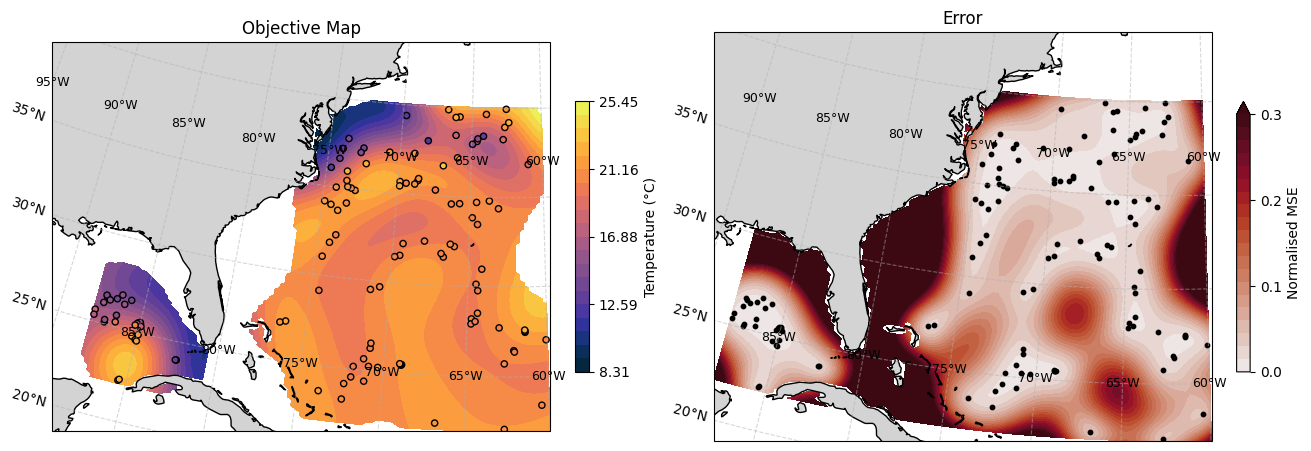

In [55]:
import regionmask
import matplotlib.colors as mcolors

# Pick an error threshold and mask the OM based on this
thresh = 0.3
mask = ergrid > thresh

map_masked = map_plot.copy()
map_masked[mask] = np.nan

# Mask the data over land
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
mask_land = land.mask(xg, yg)

map_ocean = np.where(np.isnan(mask_land), map_masked.T, np.nan)
ergrid_ocean = np.where(np.isnan(mask_land), ergrid.T, np.nan)


# Colormap limits
Tmin = np.nanmin(map_plot)
Tmax = np.nanmax(map_plot)
levels = np.linspace(Tmin, Tmax, 21)
norm = mcolors.Normalize(vmin=Tmin, vmax=Tmax, clip=True)


# Plot the objective map as contours and the original data as scatters on top
fig, ax = plt.subplots(
    1, 2,
    figsize=(13, 5),
    subplot_kw={'projection': proj},
    constrained_layout=True
)


cf = ax[0].contourf(
    xg, yg,
    map_ocean,
    levels = levels,
    norm = norm,
    cmap=cmocean.cm.thermal,
    transform=ccrs.PlateCarree()
)


sc = ax[0].scatter(
    x, y,
    c=data,
    cmap=cmocean.cm.thermal,
    s=20,
    norm = norm,
    transform=ccrs.PlateCarree(),
    edgecolor = 'k'
)


ax[0].coastlines()
ax[0].add_feature(cfeature.LAND, facecolor='lightgray')
ax[0].set_title("Objective Map")

cbar0 = fig.colorbar(
    cf,
    ax=ax[0],
    orientation='vertical',
    pad=0.02,
    shrink=0.55
)
cbar0.set_label("Temperature (°C)")
cbar0.set_ticks(np.linspace(Tmin, Tmax, 5))

gl = ax[0].gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 9, 'rotation': 0, 'ha': 'center'}

# Plot the error map as contours
erlevels = np.linspace(0, thresh, 21)
ernorm = mcolors.Normalize(vmin=0, vmax=thresh, clip=True)

cf1 = ax[1].contourf(
    xg, yg,
    ergrid_ocean,
    levels = erlevels,
    cmap=cmocean.cm.amp,
    norm = ernorm,
    transform=ccrs.PlateCarree(),
    extend='max'
)

ax[1].coastlines()
ax[1].add_feature(cfeature.LAND, facecolor='lightgray')
ax[1].set_title("Error")

cbar1 = fig.colorbar(
    cf1,
    ax=ax[1],
    orientation='vertical',
    pad=0.02,
    shrink=0.55
)
cbar1.set_label("Normalised MSE")
cbar1.set_ticks(np.linspace(0, thresh, 4))

sc1 = ax[1].scatter(
    x, y,
    c='k',
    s=10,
    transform=ccrs.PlateCarree(),
    edgecolor = 'k'
)

gl = ax[1].gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 9, 'rotation': 0, 'ha': 'center'}

plt.show()